/tmp/ipykernel_2583401/3582581632.py:31: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


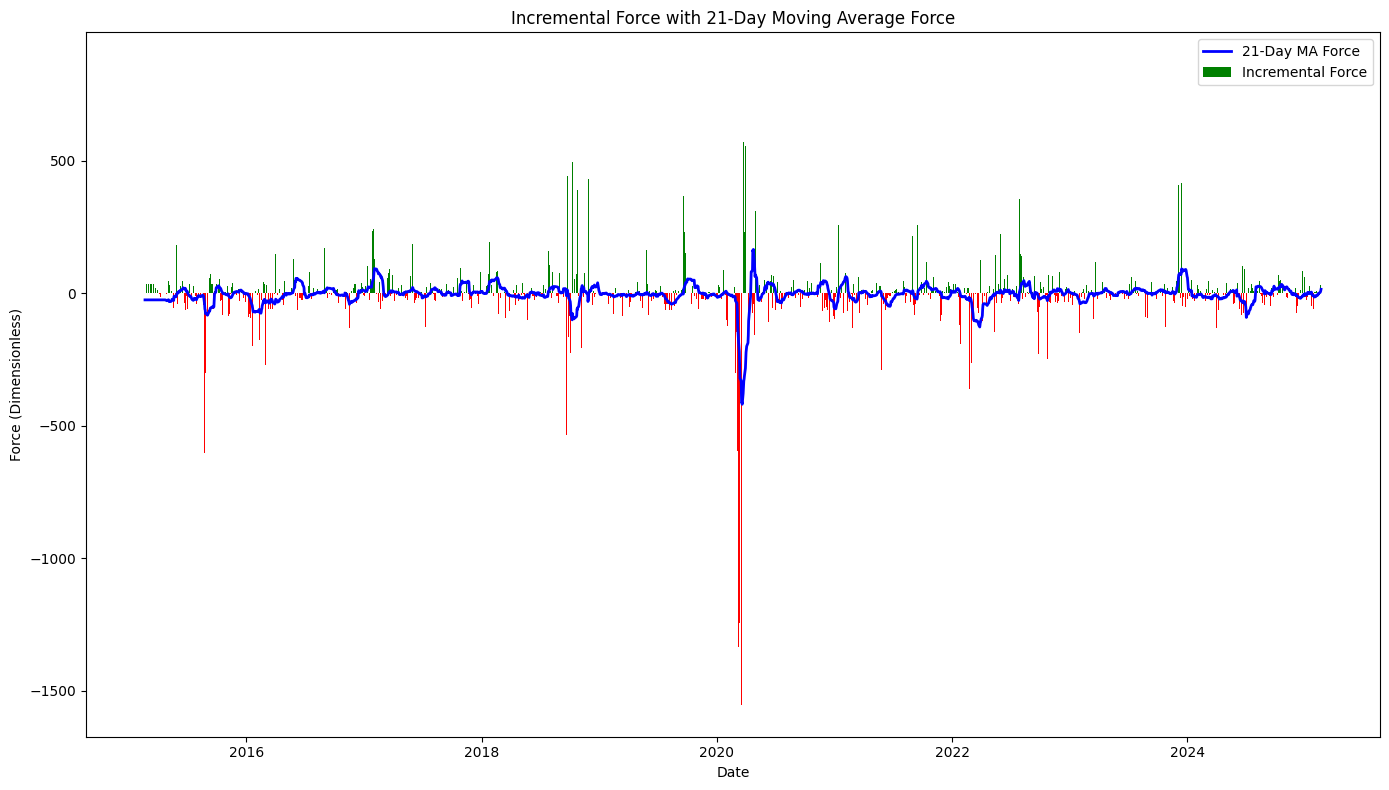

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the NIFTY OHLC data
df = pd.read_csv('/home/qa/runtime/data/analysis_out/garch/nifty_1d_10y.csv', parse_dates=['Date'], index_col='Date')
df.sort_index(inplace=True)

# Define the period (21 days)
period = 21

# Calculate the 21-day Simple Moving Average (SMA) of the Close price.
df['SMA_21'] = df['Close'].rolling(window=period).mean()

# Calculate the 21-day Average Daily Volume (ADV)
df['ADV_21'] = df['Volume'].rolling(window=period).mean()

# Calculate percentage change in price relative to SMA
df['Pct_Price_Change'] = ((df['Close'] - df['SMA_21']) / df['SMA_21']) * 100

# Calculate percentage change in volume relative to ADV
df['Pct_Volume_Change'] = ((df['Volume'] - df['ADV_21']) / df['ADV_21']) * 100

# Calculate Incremental Force as the product of the two percentage changes
df['Incremental_Force'] = df['Pct_Price_Change'] * df['Pct_Volume_Change']

# Compute the 21-day moving average of the incremental force
df['Force_MA'] = df['Incremental_Force'].rolling(window=period).mean()

# Handle NaN values from rolling calculations
df.fillna(method='bfill', inplace=True)

# -----------------------------
# Plotting: Incremental Force with Upward (green) and Downward (red) force,
# plus the 21-day moving average force
# -----------------------------
plt.figure(figsize=(14, 8))

# Plot incremental force as bars with colors based on sign
colors = np.where(df['Incremental_Force'] >= 0, 'green', 'red')
plt.bar(df.index, df['Incremental_Force'], color=colors, label='Incremental Force', width=1)

# Plot the 21-day moving average force as a blue line
plt.plot(df.index, df['Force_MA'], color='blue', linewidth=2, label='21-Day MA Force')

plt.title('Incremental Force with 21-Day Moving Average Force')
plt.xlabel('Date')
plt.ylabel('Force (Dimensionless)')
plt.legend()
plt.tight_layout()
plt.show()
